# Notebook 3: VADER Baseline Model
## Boris Letić (E2 126/2025) | Bitcoin Sentiment Analysis

**Purpose:** Establish baseline performance with rule-based sentiment analysis

**Models:**
1. VADER Simple (direct classification)
2. VADER + Logistic Regression (ML enhancement)

**Output:** Baseline metrics to compare against deep learning models

## 1. Setup

In [34]:
import pandas as pd
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
import os
import json

warnings.filterwarnings('ignore')
tqdm.pandas()
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

print("✓ Setup complete")

✓ Setup complete


## 2. Load Data

In [35]:
df = pd.read_csv('data/processed/tweets_preprocessed.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
print(f"✓ Loaded {len(df):,} tweets")

✓ Loaded 12,120 tweets


## 3. Train/Test Split (80/20)

In [36]:
df = df.sort_values('datetime').reset_index(drop=True)
split = int(len(df) * 0.8)
train = df.iloc[:split].copy()
test = df.iloc[split:].copy()

print(f"Train: {len(train):,} | Test: {len(test):,}")
print(f"Train: {train['datetime'].min().date()} to {train['datetime'].max().date()}")
print(f"Test:  {test['datetime'].min().date()} to {test['datetime'].max().date()}")

Train: 9,696 | Test: 2,424
Train: 2024-01-01 to 2024-04-24
Test:  2024-04-24 to 2024-05-31


## 4. VADER Simple Baseline

In [37]:
vader = SentimentIntensityAnalyzer()

def vader_classify(text):
    if pd.isna(text) or text == "": return 'neutral'
    compound = vader.polarity_scores(text)['compound']
    if compound >= 0.05: return 'positive'
    elif compound <= -0.05: return 'negative'
    else: return 'neutral'

print("Applying VADER to test set...")
test['vader_pred'] = test['text_cleaned'].progress_apply(vader_classify)
test['vader_compound'] = test['text_cleaned'].progress_apply(
    lambda x: vader.polarity_scores(x)['compound'] if pd.notna(x) and x else 0.0
)
print("✓ VADER predictions complete")

Applying VADER to test set...


100%|██████████| 2424/2424 [00:00<00:00, 56651.04it/s]

✓ VADER predictions complete


## 5. VADER Simple - Evaluation

In [38]:
y_true = test['sentiment'].values
y_pred_vader = test['vader_pred'].values

vader_acc = accuracy_score(y_true, y_pred_vader)
vader_f1 = f1_score(y_true, y_pred_vader, average='weighted')

print(f"VADER Simple:")
print(f"  Accuracy: {vader_acc:.4f} ({vader_acc*100:.2f}%)")
print(f"  F1-Score: {vader_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_true, y_pred_vader, digits=4))

cm_vader = confusion_matrix(y_true, y_pred_vader, labels=['positive','neutral','negative'])
print(f"\nConfusion Matrix:")
print(cm_vader)

VADER Simple:
  Accuracy: 0.4183 (41.83%)
  F1-Score: 0.4194

Classification Report:
              precision    recall  f1-score   support

    negative     0.4781    0.4761    0.4771       481
     neutral     0.4538    0.3910    0.4200      1105
    positive     0.3555    0.4212    0.3856       838

    accuracy                         0.4183      2424
   macro avg     0.4291    0.4294    0.4276      2424
weighted avg     0.4246    0.4183    0.4194      2424


Confusion Matrix:
[[353 350 135]
 [558 432 115]
 [ 82 170 229]]


## 6. VADER + Logistic Regression

In [39]:
def get_vader_features(text):
    if pd.isna(text) or text == "": return {'pos':0,'neg':0,'neu':1,'compound':0}
    return vader.polarity_scores(text)

print("Extracting VADER features...")
train_feats = pd.DataFrame(train['text_cleaned'].progress_apply(get_vader_features).tolist())
test_feats = pd.DataFrame(test['text_cleaned'].progress_apply(get_vader_features).tolist())

label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
y_train = train['sentiment'].map(label_map).values
y_test = test['sentiment'].map(label_map).values

scaler = StandardScaler()
X_train = scaler.fit_transform(train_feats.values)
X_test = scaler.transform(test_feats.values)

print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
label_inv = {v:k for k,v in label_map.items()}
y_pred_lr_labels = np.array([label_inv[p] for p in y_pred_lr])

print("✓ VADER + LR complete")

Extracting VADER features...


100%|██████████| 2424/2424 [00:00<00:00, 46752.10it/s]

Training Logistic Regression...
✓ VADER + LR complete


## 7. VADER + LR - Evaluation

In [40]:
lr_acc = accuracy_score(y_true, y_pred_lr_labels)
lr_f1 = f1_score(y_true, y_pred_lr_labels, average='weighted')

print(f"VADER + Logistic Regression:")
print(f"  Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)")
print(f"  F1-Score: {lr_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_true, y_pred_lr_labels, digits=4))

cm_lr = confusion_matrix(y_true, y_pred_lr_labels, labels=['positive','neutral','negative'])
print(f"\nConfusion Matrix:")
print(cm_lr)

VADER + Logistic Regression:
  Accuracy: 0.5590 (55.90%)
  F1-Score: 0.5496

Classification Report:
              precision    recall  f1-score   support

    negative     0.4765    0.4844    0.4804       481
     neutral     0.5788    0.7176    0.6408      1105
    positive     0.5823    0.3926    0.4690       838

    accuracy                         0.5590      2424
   macro avg     0.5459    0.5316    0.5301      2424
weighted avg     0.5597    0.5590    0.5496      2424


Confusion Matrix:
[[329 370 139]
 [195 793 117]
 [ 41 207 233]]


## 8. Model Comparison

In [41]:
comparison = pd.DataFrame({
    'Model': ['VADER Simple', 'VADER + LR'],
    'Accuracy': [vader_acc, lr_acc],
    'F1-Score': [vader_f1, lr_f1]
})

print(comparison.to_string(index=False))
print(f"\nBest: {'VADER + LR' if lr_acc > vader_acc else 'VADER Simple'}")
print(f"Improvement: {abs(lr_acc - vader_acc)*100:.2f} pp")

       Model  Accuracy  F1-Score
VADER Simple  0.418317  0.419442
  VADER + LR  0.558993  0.549583

Best: VADER + LR
Improvement: 14.07 pp


## 9. Confusion Matrices

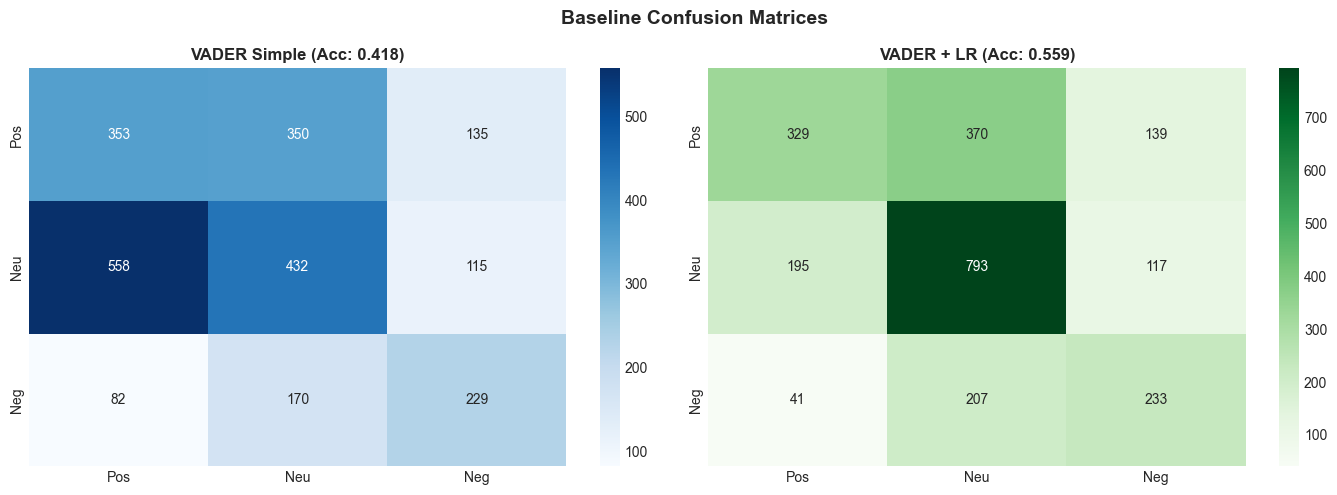

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_vader, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pos','Neu','Neg'], yticklabels=['Pos','Neu','Neg'],
            ax=axes[0])
axes[0].set_title(f'VADER Simple (Acc: {vader_acc:.3f})', fontweight='bold')

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pos','Neu','Neg'], yticklabels=['Pos','Neu','Neg'],
            ax=axes[1])
axes[1].set_title(f'VADER + LR (Acc: {lr_acc:.3f})', fontweight='bold')

plt.suptitle('Baseline Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Error Analysis

In [43]:
test['lr_pred'] = y_pred_lr_labels
errors = test[test['sentiment'] != test['lr_pred']].copy()

print(f"Total errors: {len(errors):,} / {len(test):,} ({len(errors)/len(test)*100:.2f}%)")
print(f"\nTop 5 misclassifications:")
for i, (idx, row) in enumerate(errors.head(5).iterrows()):
    print(f"\n[{i+1}] True: {row['sentiment']} | Pred: {row['lr_pred']}")
    print(f"    VADER: {row['vader_compound']:+.3f}")
    print(f"    Text: {row['text_cleaned'][:70]}...")

Total errors: 1,069 / 2,424 (44.10%)

Top 5 misclassifications:

[1] True: positive | Pred: negative
    VADER: -0.477
    Text: bitcoin fixes everything prove me wrong...

[2] True: neutral | Pred: positive
    VADER: +0.402
    Text: interesting bitcoin discussion on the podcast today imo...

[3] True: positive | Pred: negative
    VADER: -0.103
    Text: bitcoin adoption is accelerating banks are scared agree...

[4] True: positive | Pred: neutral
    VADER: +0.000
    Text: bitcoin network hashrate at all time high bullish...

[5] True: positive | Pred: neutral
    VADER: +0.000
    Text: not selling until we hit six figures btc level...


## 11. Export Results

In [44]:
os.makedirs('results/baseline', exist_ok=True)

# Save predictions
test[['datetime','text','sentiment','vader_pred','vader_compound','lr_pred']].to_csv(
    'results/baseline/vader_predictions.csv', index=False
)

# Save metrics
metrics = {
    'vader_simple': {'accuracy': float(vader_acc), 'f1': float(vader_f1)},
    'vader_lr': {'accuracy': float(lr_acc), 'f1': float(lr_f1)},
    'test_size': len(test),
    'error_count': len(errors)
}

with open('results/baseline/vader_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("✓ Saved: results/baseline/vader_predictions.csv")
print("✓ Saved: results/baseline/vader_metrics.json")

✓ Saved: results/baseline/vader_predictions.csv
✓ Saved: results/baseline/vader_metrics.json
